In [1]:
from DFTStructureGenerator import B_N_Cl
import glob, os
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from tqdm import tqdm
import pandas as pd
import pickle

In [2]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from catboost import CatBoostRegressor, CatBoostClassifier
from matplotlib import pyplot as plt

In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [4]:
# PhysOrg
all_descriptors_names = [
    "C_Cl react deltaG", "C_Cl Cl_charge", "C_Cl C_charge", "C_Cl Cl_Hirshfield_charge", "C_Cl C_Hirshfield_charge", 
    "C_Cl MaxOtherCharge", "C_Cl MinOtherCharge", "C_Cl MaxChargeDist", "C_Cl MinOtherChargeDist", 
    "C_Cl MaxOtherHCharge", "C_Cl MinOtherHCharge", "C_Cl MaxHChargeDist", "C_Cl MinHOtherChargeDist", 
    "C_Cl MaxAromaticRingCharge", "C_Cl MinAromaticRingCharge", "C_Cl MaxAromaticChargeDist", "C_Cl MinAromaticChargeDist",
    "C_Cl C_Cl_dist", 
    "C_Cl HOMO-1", "C_Cl HOMO", "C_Cl LUMO", "C_Cl LUMO+1", "C_Cl dipole", "C_Cl Bv2radius", "C_Cl Bv4radius", "C_Cl Bv6radius", "C C_charge", "C C_spin", "C C_Hirshfield_charge", 
    "C Alpha-HOMO-1", "C Alpha-HOMO", "C Alpha-LUMO", "C Alpha-LUMO+1", "C Beta-HOMO-1", "C Beta-HOMO", "C Beta-LUMO", "C Beta-LUMO+1", "C_dipole",
    
    "B_G", "B_HOMO-1", "B_HOMO", "B_LUMO", "B_LUMO+1", "B_HOMO-1_B", "B_HOMO_B", "B_LUMO_B", "B_LUMO+1_B", "B_dipole", "B_spin",
    # "B_Cl_G", "B_Cl_HOMO-1", "B_Cl_HOMO", "B_Cl_LUMO", "B_Cl_LUMO+1", "B_Cl_dipole", "B_Cl_Charge_B", "B_Cl_Charge_Cl", "B_Cl_Bond_B_Cl", "B_Cl_BV_2A", "B_Cl_BV_4A", "B_Cl_BV_6A",
    
    "Ini_G", "Ini_HOMO-1", "Ini_HOMO", "Ini_LUMO", "Ini_LUMO+1", "Ini_dipole", "Ini_T","Ini_Charge_N", "Ini_Charge_C", "Ini_Bond_N_C", "Ini_BV_2A", "Ini_BV_4A", "Ini_BV_6A",
    "Sol_G", "Sol_HOMO-1", "Sol_HOMO", "Sol_LUMO", "Sol_LUMO+1", "Sol_dipole", "Sol_x",
    "S_G", "S_HOMO-1", "S_HOMO", "S_LUMO", "S_LUMO+1", "S_dipole", "S_Charge_S", "S_Charge_C", "S_Bond_S_C", "S_BV_2A", "S_BV_4A", "S_BV_6A",
    "B_eq",
    ]
len(all_descriptors_names)

82

# 1. Load Descriptors 

In [6]:
with open("Data/PhysOrgdes_new.pkl", 'rb') as f:
    index_map = pickle.load(f)

In [7]:
with open("Data/Cldes_new.pkl", 'rb') as f:
    Cl_des_map = pickle.load(f)

# 2. Bayesian Optimization

## 2.1 Full Data Space Comfirm

In [5]:
react_df = pd.read_csv('Data/Processed_Reactants.csv')
all_smiles = list(set(react_df['Smiles'].to_list()))
B_df = react_df.loc[react_df['Type'] == "B"]
S_df = react_df.loc[react_df['Type'] == "S"]
ini_df = react_df.loc[react_df['Type'] == "ini"]
sol_df = react_df.loc[react_df['Type'] == "sol"]
eqs = [1.5, 2.0, 2.5, 3.0]
target_idx = np.array(np.meshgrid(np.arange(len(B_df['Index'])), np.arange(len(S_df['Index'])), np.arange(len(ini_df['Index'])), np.arange(len(sol_df['Index'])), np.arange(len(eqs)))).T.reshape(-1, 5)
B_mols = [Chem.MolFromSmiles(smi) for smi in B_df['Smiles']]
S_mols = [Chem.MolFromSmiles(smi) for smi in S_df['Smiles']]
ini_mols = [Chem.MolFromSmiles(smi) for smi in ini_df['Smiles']]
B_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=8)) for mol in B_mols])
S_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=8)) for mol in S_mols])
ini_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=8)) for mol in ini_mols])
sol_fps = np.eye(len(sol_df))
eqs_fps = np.eye(len(eqs))
B_mfps = B_fps @ B_fps.T
S_mfps = S_fps @ S_fps.T
ini_mfps = ini_fps @ ini_fps.T
sol_mfps = sol_fps
eqs_mfps = eqs_fps
 
# S_index_dict{0: 2000}
B_index_dict = {idx:id_ for idx, id_ in enumerate(B_df['Index'])}
S_index_dict = {idx:id_ for idx, id_ in enumerate(S_df['Index'])}
ini_index_dict = {idx:id_ for idx, id_ in enumerate(ini_df['Index'])}
sol_index_dict = {idx:id_ for idx, id_ in enumerate(sol_df['Index'])}
eqs_index_dict = {idx:id_ for idx, id_ in enumerate(eqs)}

[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerator
[15:13:52] DEPRECATION WARNING: please use MorganGenerat

## 2.2 Descriptors for Optimization

### 2.2.1 Descriptors for Meta-Site Optimization

In [8]:
all_des = []
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)


205632it [00:00, 496596.09it/s]


### 2.2.2 Descriptors for Ortho-Site Optimization

In [40]:
all_des = []
Cl = 5001
Cl_atomid = 19
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    if Cl in [5001, 5002]:
        desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
    else:
        desc += Cl_des_map[f"Cl_{Cl:05d}"]
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)
full_space_X.shape

222768it [00:00, 303248.16it/s]


(222768, 82)

### 2.2.3 Descriptors for Para-Site Optimization

In [11]:
all_des = []
Cl = 5002
Cl_atomid = 17
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    if Cl in [5001, 5002]:
        desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
    else:
        desc += Cl_des_map[f"Cl_{Cl:05d}"]
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)
full_space_X.shape

222768it [00:00, 291084.47it/s]


(222768, 82)

### 2.2.4 Descriptors for Migration Optimization

In [94]:
all_des = []
Cl = 5003       # Cl Required for Migration
Cl_atomid = 11
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    if Cl in [5001, 5002, 5003, 5004]:
        desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
    else:
        desc += Cl_des_map[f"Cl_{Cl:05d}"]
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)
full_space_X.shape

222768it [00:00, 292499.54it/s]


(222768, 82)

## 2.3 Load Dropped Dataset

In [9]:
with open("Data/Iteration/drop_n.pkl", 'rb') as f:
    droped_n = pickle.load(f)
with open("Data/Iteration/drop_p.pkl", 'rb') as f:
    droped_p = pickle.load(f)

In [13]:
all_droped = 0
for a,b in zip(droped_n, droped_p):
    if a or b:
        all_droped += 1
all_droped

15683

In [12]:
np.sum(droped_n), np.sum(droped_p)

(2751, 15683)

## 2.4 Selection Function

In [41]:
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker
# def distanceij(i,j):                    # Use for First Dataset Selection
#     return 1 - generate_similarity(i,j)

def distanceij(i,j):                    # Use forb Optimization
    return uncertainty[i] * 1 + get_avaliable(i) * 1000 + all_result[i] * 1 


def generate_similarity(i,j):
    k = B_mfps[target_idx[i][0]][target_idx[j][0]] + S_mfps[target_idx[i][1]][target_idx[j][1]] + ini_mfps[target_idx[i][2]][target_idx[j][2]] + sol_mfps[target_idx[i][3]][target_idx[j][3]] + eqs_mfps[target_idx[i][4]][target_idx[j][4]]
    return k / (B_mfps[target_idx[i][0]][target_idx[i][0]] + S_mfps[target_idx[i][1]][target_idx[i][1]] + ini_mfps[target_idx[i][2]][target_idx[i][2]] +
                sol_mfps[target_idx[i][3]][target_idx[i][3]] + eqs_mfps[target_idx[i][4]][target_idx[i][4]] +
                B_mfps[target_idx[j][0]][target_idx[j][0]] + S_mfps[target_idx[j][1]][target_idx[j][1]] + ini_mfps[target_idx[j][2]][target_idx[j][2]] +
                sol_mfps[target_idx[j][3]][target_idx[j][3]] + eqs_mfps[target_idx[j][4]][target_idx[j][4]]
                - k) 

def generate_uncertainty(train_X, train_y, test_X):
    model = CatBoostRegressor(iterations=10000, random_seed=0, verbose=0, depth=2, loss_function="RMSEWithUncertainty")
    model.fit(train_X, train_y)
    return model.predict(test_X).T

def get_avaliable(i):
    # if droped_n[i]:
    #     return 0
    # if droped_p[i]:
    #     return 0
    if target_idx[i][0] in [3]:
        return 0
    if target_idx[i][3] in [11]:
        return 0
    return 1

# picker = MaxMinPicker()
# picker_idx = picker.LazyPick(distanceij, len(target_idx), 50, firstPicks=[0])
# list(picker_idx)

In [14]:
if not os.path.isdir("Data/Iteration/"):
    os.mkdir("Data/Iteration/")

## 2.5 Generate Uncertainty

In [ ]:
Times = 22

In [ ]:
all_X_qm, yields = B_N_Cl.descriptor_generator(f"Data/Iteration/Result_sum_{Times - 1:05}.xlsx", index_map, Cl_des_map)

In [43]:
all_result, uncertainty = generate_uncertainty(train_X = all_X_qm, train_y=yields, test_X=full_space_X)
len(uncertainty)

222768

In [44]:
if Times > 0:
    first_iter = np.load(f"Data/Iteration/picker_{Times - 1:05}.npy")
    each_size = 10
else:
    first_iter = []
    each_size = 50
print(len(first_iter))
picker = MaxMinPicker()
picker_idx = picker.LazyPick(distanceij, len(target_idx), len(first_iter) + each_size, firstPicks=first_iter.tolist())

120


In [45]:
np.save(f"Data/Iteration/picker_{Times:05}.npy", np.array(picker_idx))
final_csv = pd.DataFrame({"B_Smiles": B_df.reset_index()['Smiles'][target_idx[picker_idx].T[0]].to_list(), "B_Index": B_df.reset_index()['Index'][target_idx[picker_idx].T[0]].to_list(), "S_Smiles": S_df.reset_index()['Smiles'][target_idx[picker_idx].T[1]].to_list(), "S_Index": S_df.reset_index()['Index'][target_idx[picker_idx].T[1]].to_list(), "ini_Smiles": ini_df.reset_index()['Smiles'][target_idx[picker_idx].T[2]].to_list(), "ini_Index": ini_df.reset_index()['Index'][target_idx[picker_idx].T[2]].to_list(), "sol_Smiles": sol_df.reset_index()['Smiles'][target_idx[picker_idx].T[3]].to_list(), "sol_Index": sol_df.reset_index()['Index'][target_idx[picker_idx].T[3]].to_list(), "sol_name": sol_df.reset_index()['Appendix'][target_idx[picker_idx].T[3]].to_list(), "eqs": np.array(eqs)[target_idx[picker_idx].T[4]]})
final_csv['Cl_Index'] = [5002] * len(final_csv)
final_csv['Cl_Atomid'] = [17] * len(final_csv)
final_csv[len(first_iter):].to_csv(f"Data/Iteration/data_{Times:05}_NEW.csv", index=False)

## 2.6 For Migration

In [96]:
final_result = uncertainty * 1 + all_result * 1
picker_idx = np.argsort(final_result)[::-1][:10]

In [134]:
Times = 3
first_iter = np.load(f"Data/Iteration2/picker_{Times - 1:05}_{Cl:04}_{Cl_atomid:04}.npy")
print(len(first_iter))
picker = MaxMinPicker()
# picker_idx = picker.LazyPick(distanceij, len(target_idx), 10, firstPicks=[])
picker_idx = picker.LazyPick(distanceij, len(target_idx), len(first_iter) + 10, firstPicks=first_iter.tolist())

30


In [135]:
np.save(f"Data/Iteration2/picker_{Times:05}_{Cl:04}_{Cl_atomid:04}.npy", np.array(picker_idx))
final_csv = pd.DataFrame({"B_Smiles": B_df.reset_index()['Smiles'][target_idx[picker_idx].T[0]].to_list(), "B_Index": B_df.reset_index()['Index'][target_idx[picker_idx].T[0]].to_list(), "S_Smiles": S_df.reset_index()['Smiles'][target_idx[picker_idx].T[1]].to_list(), "S_Index": S_df.reset_index()['Index'][target_idx[picker_idx].T[1]].to_list(), "ini_Smiles": ini_df.reset_index()['Smiles'][target_idx[picker_idx].T[2]].to_list(), "ini_Index": ini_df.reset_index()['Index'][target_idx[picker_idx].T[2]].to_list(), "sol_Smiles": sol_df.reset_index()['Smiles'][target_idx[picker_idx].T[3]].to_list(), "sol_Index": sol_df.reset_index()['Index'][target_idx[picker_idx].T[3]].to_list(), "sol_name": sol_df.reset_index()['Appendix'][target_idx[picker_idx].T[3]].to_list(), "eqs": np.array(eqs)[target_idx[picker_idx].T[4]]})
final_csv['Cl_Index'] = [Cl] * len(final_csv)
final_csv['Cl_Atomid'] = [Cl_atomid] * len(final_csv)
final_csv['PredValue'] = all_result[picker_idx]
final_csv[len(first_iter):].to_csv(f'Data/Iteration2/{Times:05}_{Cl:04}_{Cl_atomid:04}.csv', index=False)

## 2.7 Delete Well Performance Conditions

### 2.7.1 Delete Well Performance Conditions in Meta-Optimization

In [183]:
all_X_qm, yields = B_N_Cl.descriptor_generator("Data/Iteration/Result_sum_00007.xlsx", index_map, Cl_des_map)
target = np.array([1 if each > 20 else 0 for each in yields])

In [184]:
all_des = []
Cl = 5000
Cl_atomid = 15
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    if Cl in [5001, 5002]:
        desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
    else:
        desc += Cl_des_map[f"Cl_{Cl:05d}"]
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)


222768it [00:00, 336924.40it/s]


In [21]:
with open("Data/Iteration/drop_n.pkl", 'rb') as f:
    droped_n = pickle.load(f)

In [28]:
model = CatBoostClassifier(iterations=10000, random_seed=0, verbose=0, depth=2)
model.fit(all_X_qm, target)
result = model.predict(full_space_X)
result_ = (result == 1) | (droped_n == 1)
with open("Data/Iteration/drop_p.pkl", "wb") as f:
    pickle.dump(result_, f)
np.sum(droped_n), np.sum(result), np.sum(result_)

(2751, 15640, 15683)

### 2.7.2 Delete Well Performance Conditions in Meta-Optimization

In [17]:
all_X_qm, yields = B_N_Cl.descriptor_generator("Data/Iteration/Result_sum_00013.xlsx", index_map, Cl_des_map)
target = np.array([1 if each > 20 else 0 for each in yields])

In [18]:
all_des = []
Cl = 5001
Cl_atomid = 19
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    if Cl in [5001, 5002]:
        desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
    else:
        desc += Cl_des_map[f"Cl_{Cl:05d}"]
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)
full_space_X.shape

222768it [00:00, 231212.60it/s]


(222768, 82)

In [ ]:
model = CatBoostClassifier(iterations=10000, random_seed=0, verbose=0, depth=2)
model.fit(all_X_qm, target)
result = model.predict(full_space_X)

# 3. Draw Performance Figure

In [7]:
def plot_plot_with_metrics(x, y, title=None, min_=None, max_=None):
    # Draw Figure
    r2 = r2_score(x, y)
    mae = mean_absolute_error(x, y)
    mse = mean_squared_error(x, y)

    plt.figure(figsize=(6, 5))
    if min_!=None and max_!=None:
        # plt.xlim(min_, max_)
        plt.ylim(min_, max_)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    # plt.xlabel("Real", fontsize=18)
    # plt.ylabel("Prediction", fontsize=18)
    if title != None:
        # plt.title("%s\nR2:%.3f, MAE:%.3f, MSE:%.3f" % (title, r2, mae, mse), fontsize=24)
        plt.title("%s"%title,fontsize=24)
    plt.plot(x, y, marker="*", c="g")

    plt.savefig(f"{title}.png", dpi=300)
    plt.show()

In [8]:
final_xlsxs = glob.glob("Data/Iteration/Result_sum_*.xlsx")
n_result, m_result, p_result = [[], []], [[], []], [[], []]
for file in final_xlsxs:
    df = pd.read_excel(file)
    if "Cl_Atomid" in df.columns and 19 in df['Cl_Atomid'].to_numpy():
        if 17 in df['Cl_Atomid'].to_numpy():
            temp_df = df[df['Cl_Atomid'] == 17]
            p_result[0].append(len(temp_df))
            p_result[1].append(np.max(np.nan_to_num(temp_df['yield'].to_numpy(), nan=0)))
        else:
            temp_df = df[df['Cl_Atomid'] == 19]
            n_result[0].append(len(temp_df))
            n_result[1].append(np.max(np.nan_to_num(temp_df['yield'].to_numpy(), nan=0)))
    else:
        temp_df = df
        m_result[0].append(len(temp_df))
        m_result[1].append(np.max(np.nan_to_num(temp_df['yield'].to_numpy(), nan=0)))


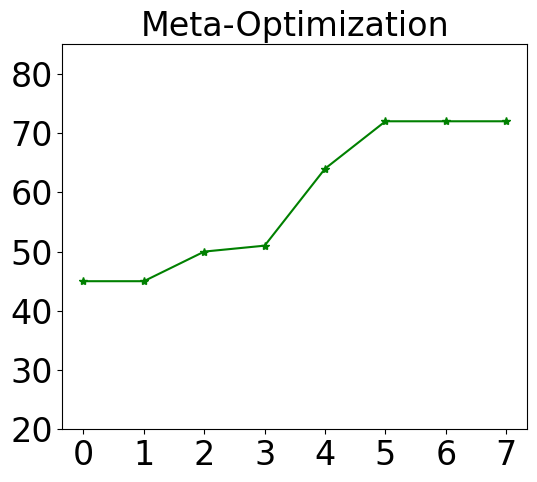

In [9]:
plot_plot_with_metrics(np.arange(0, len(m_result[1])), m_result[1], "Meta-Optimization", min_=20, max_=85)

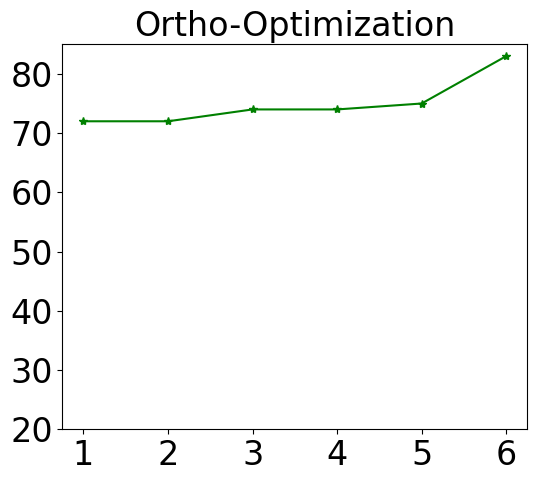

In [17]:
plot_plot_with_metrics(np.arange(1, len(n_result[1]) + 1), n_result[1], "Ortho-Optimization", min_=20, max_=85)

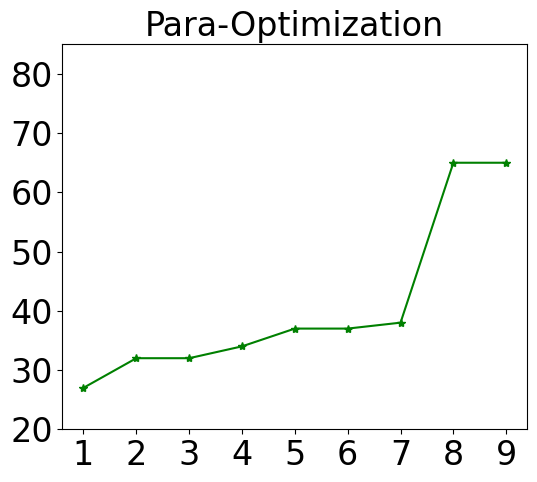

In [18]:
plot_plot_with_metrics(np.arange(1, len(p_result[1]) + 1), p_result[1], "Para-Optimization", min_=20, max_=85)

In [20]:
final_xlsxs = glob.glob("Data/Iteration2/*5003*.xlsx")
migrate_result = [[], []]
for file in final_xlsxs:
    df = pd.read_excel(file)
    if "Cl_Atomid" in df.columns and 5003 in df['Cl_Index'].to_numpy():
            temp_df = df[df['Cl_Index'] == 5003]
            migrate_result[0].append(len(temp_df))
            migrate_result[1].append(np.max(np.nan_to_num(temp_df['yield'].to_numpy(), nan=0)))


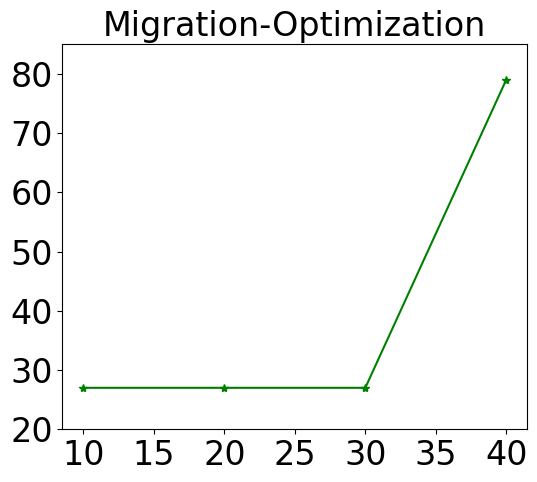

In [21]:
plot_plot_with_metrics(migrate_result[0], migrate_result[1], "Migration-Optimization", min_=20, max_=85)

In [10]:
from sklearn.model_selection import cross_val_score
all_r2, all_mae = [], []
for eachfile in final_xlsxs:
    all_X_qm, yields = B_N_Cl.descriptor_generator(eachfile, index_map, Cl_des_map)
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    all_X = all_X_qm
    result_matrix = np.zeros((2, 2))
    target = yields
    temp_r2, temp_mae = [], []
    for train_ids, test_ids in kf.split(all_X):
        model = CatBoostRegressor(iterations=10000, random_seed=0, verbose=0, depth=2)
        model.fit(all_X[train_ids], target[train_ids])
        pred = model.predict(all_X[test_ids])
        r2 = r2_score(target[test_ids], pred)
        mae = mean_absolute_error(target[test_ids], pred)
        temp_r2.append(r2)
        temp_mae.append(mae)
    all_r2.append(np.mean(temp_r2))
    all_mae.append(np.mean(temp_mae))
    print(all_r2[-1], all_mae[-1])                         


-2.541829782945582 2.780736329232563
-0.023590584007627237 5.878256384106833
-0.5046912022182373 8.561698656816088
0.4672065446712182 9.121178157725138
0.7123487736653658 7.467771539358902
0.6706388633918356 8.471388872188449
0.7386532143068321 8.514755280570691
0.7022277015086533 9.932662893530736
0.6925554127721333 10.263302903725254
0.7953203946721138 8.982792932546683
0.7198775433564018 10.71302486002368
0.772141674944623 10.087124167832169
0.7807233309909657 9.9122086841613
0.7840174923243334 9.826741605443058
0.792071088631935 9.603780687086
0.7710275337809499 9.744490791658828
0.7764929025862083 9.538977881168368
0.8007076046213392 9.063244484825072
0.7973005828971461 8.747954536255719
0.7440550495659706 9.140460891281943
0.7806170845564575 8.53682421124859
0.7315462452723719 9.30677736897845
0.7009988889777323 9.675323166591513


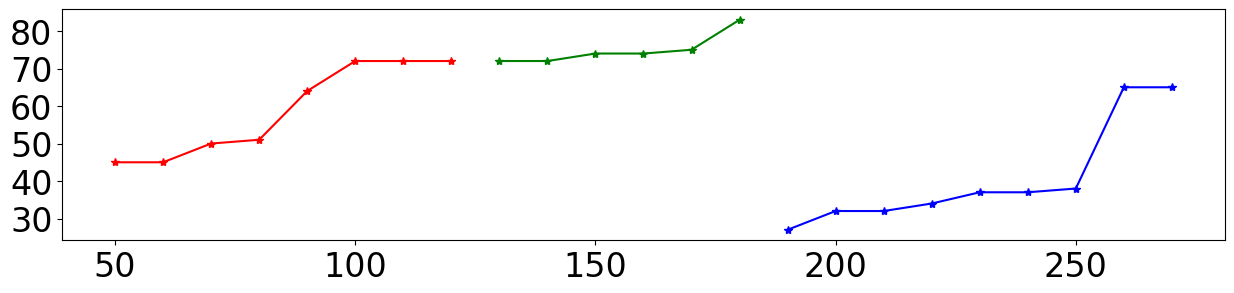

In [11]:
plt.figure(figsize=(15,3))
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.plot(m_result[0], m_result[1], c='red', marker="*")
plt.plot(np.array(n_result[0]) + m_result[0][-1], n_result[1], c='green', marker="*")
plt.plot(np.array(p_result[0]) + n_result[0][-1] + m_result[0][-1], p_result[1], c='blue', marker="*")
plt.savefig('Figure/Figure2_yield.png', dpi=300, bbox_inches='tight')

(0.0, 1.0)

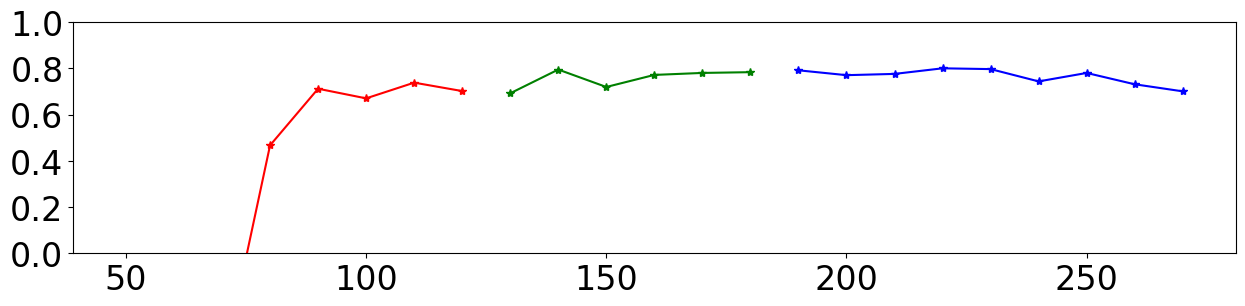

In [12]:
plt.figure(figsize=(15,3))
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
x = np.arange(50, 280, 10)
plt.plot(x[:len(m_result[0])], all_r2[:len(m_result[0])], c='red', marker="*")
plt.plot(x[len(m_result[0]):len(m_result[0]) + len(n_result[0])], all_r2[len(m_result[0]):len(m_result[0]) + len(n_result[0])], c='green', marker="*")
plt.plot(x[len(m_result[0]) + len(n_result[0]):], all_r2[len(m_result[0]) + len(n_result[0]):], c='blue', marker="*")
plt.ylim(0, 1)
# plt.plot(np.array(n_result[0]) + m_result[0][-1], n_result[1], c='green', marker="*")
# plt.plot(np.array(p_result[0]) + n_result[0][-1] + m_result[0][-1], p_result[1], c='blue', marker="*")
# plt.savefig('Figure/Figure2_yield.png', dpi=300, bbox_inches='tight')

In [ ]:
df = pd.DataFrame({'Meta_EXP':m_result[0], 'Meta_Yield': m_result[1], 'Ortho_EXP': n_result[0], 'Ortho_Yield': n_result[1], 'Para_EXP': p_result[0], 'Para_Yield': p_result[1], 'R2_EXP': x, 'R2_Yield': all_r2})

In [48]:
df = pd.DataFrame([m_result[0], m_result[1], n_result[0], n_result[1], p_result[0], p_result[1], x, all_r2])

In [182]:
import matplotlib.pyplot as plt
import numpy as np


def plot_dual_axis(
    x,
    r2_mean,
    best_values,
    line_color='C0',
    scatter_color=None,
    figsize=(10, 5.2),
    line_marker='o',
    scatter_size=100,
    range_r2=(-3, 1),
    range_best_values=(40, 80),
    labelsize=30,
    save_path='Figure/Figure2_yield.png'
):

    fig, ax1 = plt.subplots(figsize=figsize)

    # 左轴
    line_a = ax1.plot(
        x, r2_mean,
        color=line_color,
        linewidth=4,
        marker=line_marker,
        markersize=10,
        markerfacecolor='white',
        markeredgewidth=1.6,
        label='5-Fold R² (mean)'
    )

    ax1.tick_params(axis='x', labelsize=labelsize)
    ax1.tick_params(axis='y', labelcolor=line_color, labelsize=labelsize)
    ax1.grid(True, linestyle='--', alpha=0.4)

    # ---------- 强制横坐标1间隔 ----------
    ax1.set_xticks(x)

    # 右轴
    ax2 = ax1.twinx()

    line_b = ax2.plot(
        x, best_values,
        color=scatter_color,
        linewidth=4,
        linestyle='--',
        marker='*',
        markersize=10,
        markerfacecolor='white',
        markeredgewidth=1.6,
        label='Best Yield'
    )


    # ax2.scatter(
    #     x, best_values,
    #     color=scatter_color,
    #     s=scatter_size,
    #     edgecolors='white',
    #     linewidth=1.4,
    #     zorder=10,
    #     label='Best value'
    # )

    ax2.tick_params(axis='y', labelcolor=scatter_color, labelsize=labelsize)

    ax1.set_ylim(*range_r2)
    ax2.set_ylim(*range_best_values)
    ax2.legend(loc='lower right', fontsize=20, handles=[line_a[0], line_b[0]])

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

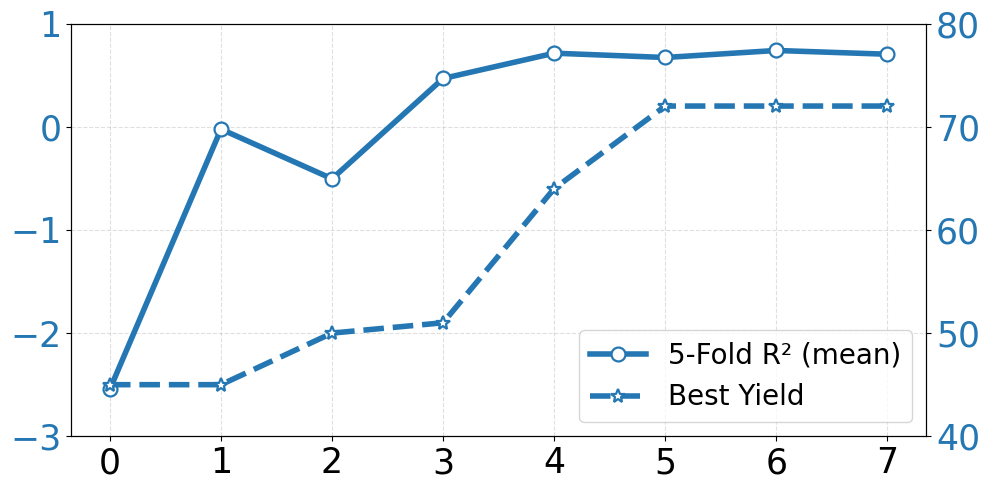

In [189]:
plot_dual_axis(
    x=np.arange(len(m_result[0])),
    best_values=m_result[1],
    r2_mean=all_r2[:len(m_result[0])],
    line_color='#2577b3',       # 朱红
    scatter_color='#2577b3',     # 深绿 / 或 '#1f77b4' 深蓝 等
    figsize=(10, 5),
    range_r2=(-3, 1),
    range_best_values=(40, 80),
    save_path='Figure/Figure3_Meta.png',
    labelsize=25
)

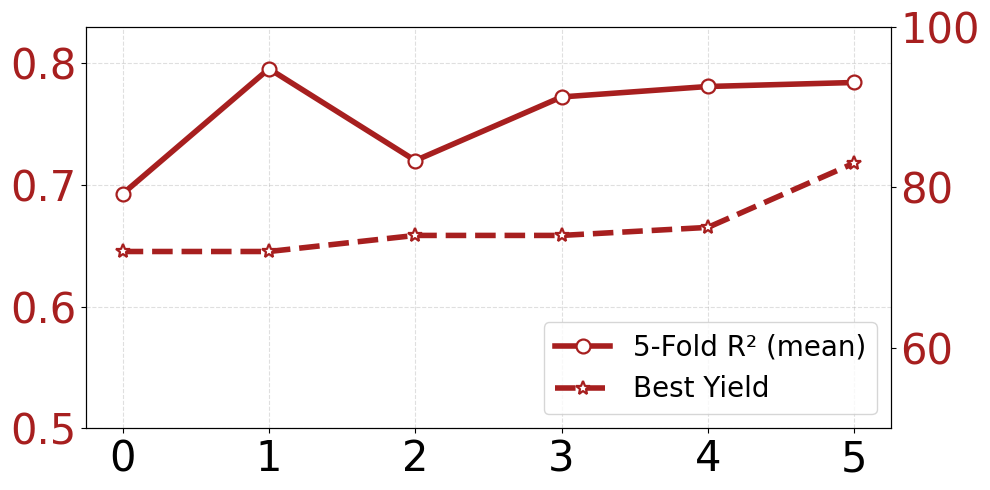

In [190]:
plot_dual_axis(
    x=np.arange(len(n_result[0])),
    best_values=n_result[1],
    r2_mean=all_r2[len(m_result[0]):len(m_result[0]) + len(n_result[0])],
    line_color="#a71f1f",       # 朱红
    scatter_color='#a71f1f',     # 深绿 / 或 '#1f77b4' 深蓝 等
    figsize=(10, 5),
    range_r2=(0.5, 0.83),
    range_best_values=(50, 100),
    save_path='Figure/Figure3_Ortho.png'
)

In [198]:
all_r2[len(m_result[0]) + len(n_result[0]):]

[0.792071088631935,
 0.7710275337809499,
 0.7764929025862083,
 0.8007076046213392,
 0.7973005828971461,
 0.7440550495659706,
 0.7806170845564575,
 0.7315462452723719,
 0.7009988889777323]

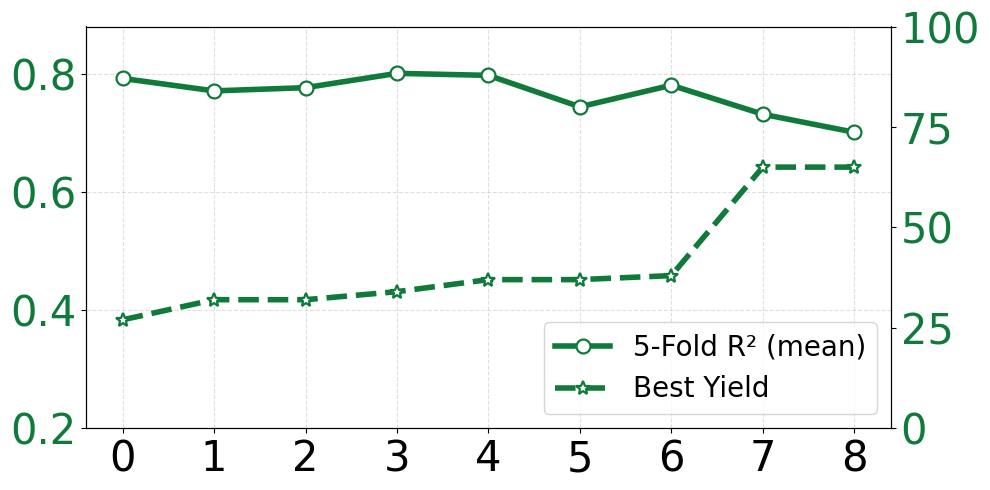

In [191]:
plot_dual_axis(
    x=np.arange(len(p_result[0])),
    best_values=p_result[1],
    r2_mean=all_r2[len(m_result[0]) + len(n_result[0]):],
    line_color='#107a3a',       # 朱红
    scatter_color='#107a3a',     # 深绿 / 或 '#1f77b4' 深蓝 等
    figsize=(10, 5),
    range_r2=(0.2, 0.88),
    range_best_values=(0, 100),
    save_path='Figure/Figure3_Para.png'
)

In [170]:
all_r2[len(m_result[0]):len(m_result[0]) + len(n_result[0])][-1]

0.7840174923243334